In [1]:
import os
os.chdir("/home/ppavlik/repos/nowcasting-SVK-dualpol")

import datasets.SlovakDatasetDualPol as SlovakDatasetDualPol

ds = SlovakDatasetDualPol(path=fr"/home/projects/p1364-25-2/datasets/SHMU_4_New",
                   metadata_folder=fr"/home/projects/p1364-25-2/datasets/SHMU_4_New/metadata",
                   split="full", denoise=True, erosion_mask=False, transform_to_mmh=False,
                   input_block_length=1, prediction_block_length=0,
                   products=['dBZ', 'RhoHV'], aggregate_vertical=False)

In [ ]:
from itertools import combinations_with_replacement, permutations
import torch
from torchmetrics.regression import PearsonCorrCoef
from torchvision.transforms.functional import center_crop

def _count_precip_corr(i):
    device = torch.device("cuda:0")
    pearson = PearsonCorrCoef().to(device)

    idx = [i]

    x, _, _ = ds[idx[0]]
    x = center_crop(x, 512).to(device)

    # number of altitude levels
    n_altitudes = x.shape[2]

    results = {}

    for z1, z2 in combinations_with_replacement(range(n_altitudes), 2):
        p1 = x[0, 0, z1]
        p2 = x[0, 0, z2]

        corr = pearson(
            p1[~torch.isnan(p1)].flatten(),
            p2[~torch.isnan(p2)].flatten()
        )

        results[(z1, z2)] = corr.cpu().item()

    return results

In [51]:
corrs = _count_precip_corr(463)

In [52]:
corrs

{(0, 0): 1.0,
 (0, 1): 0.9835953712463379,
 (0, 2): 0.9669346213340759,
 (0, 3): 0.9507670998573303,
 (0, 4): 0.9348472952842712,
 (0, 5): 0.9172345995903015,
 (0, 6): 0.8982283473014832,
 (0, 7): 0.8731780648231506,
 (0, 8): 0.8422464728355408,
 (0, 9): 0.8103201389312744,
 (0, 10): 0.7719889283180237,
 (0, 11): 0.7305759191513062,
 (0, 12): 0.6817019581794739,
 (0, 13): 0.6398234963417053,
 (0, 14): 0.597545325756073,
 (0, 15): 0.5447004437446594,
 (1, 1): 1.0,
 (1, 2): 0.9842056035995483,
 (1, 3): 0.9689380526542664,
 (1, 4): 0.9525768756866455,
 (1, 5): 0.9342358112335205,
 (1, 6): 0.9153016209602356,
 (1, 7): 0.8886538147926331,
 (1, 8): 0.8544095158576965,
 (1, 9): 0.8218229413032532,
 (1, 10): 0.7824350595474243,
 (1, 11): 0.7398006916046143,
 (1, 12): 0.6902674436569214,
 (1, 13): 0.6480523347854614,
 (1, 14): 0.6042472720146179,
 (1, 15): 0.5499248504638672,
 (2, 2): 1.0,
 (2, 3): 0.9840642809867859,
 (2, 4): 0.9696918725967407,
 (2, 5): 0.9514853358268738,
 (2, 6): 0.93279522

In [14]:
x, _, _ = ds[24173]
#x = center_crop(x, 512)

In [16]:
x[0,0,0].shape

torch.Size([517, 755])

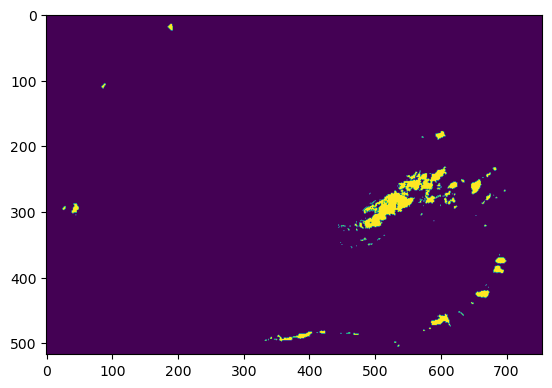

In [30]:
plt.imshow(x[0,0,0].cpu() > 20)

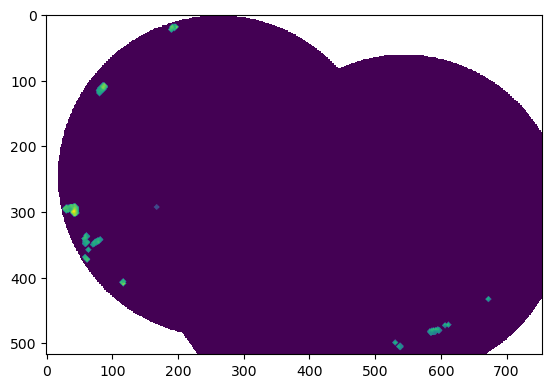

In [63]:
import matplotlib.pyplot as plt

plt.imshow(x[0,0,11].cpu(), cmap='viridis')

In [54]:
import numpy as np

corr_matrix = np.empty((16, 16))
corr_matrix[:] = np.nan

for corr in corrs:
    corr_matrix[corr] = corrs[corr]

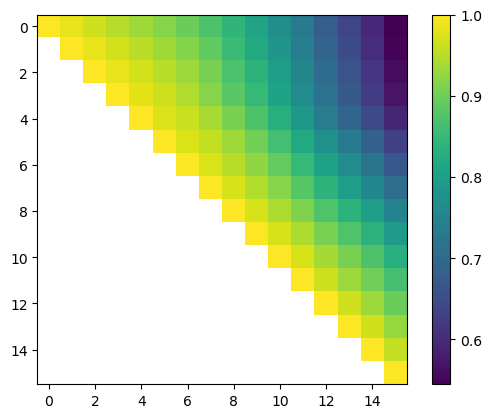

In [55]:
plt.imshow(corr_matrix, vmax=1)
plt.colorbar()

In [30]:
from tqdm import tqdm

corrs = []

for i in tqdm(range(len(ds))):
    pearson_corrs = _count_precip_corr(i)
    corrs.append(pearson_corrs)

  0%|          | 26/25358 [00:37<10:03:40,  1.43s/it]


KeyboardInterrupt: 

In [7]:
from collections import defaultdict

def sum_dicts_by_key(dicts):
    out = defaultdict(float)
    for d in dicts:
        for k, v in d.items():
            out[k] += v
    return dict(out)

def scale_dict(d, c):
    return {k: v / c for k, v in d.items()}

In [ ]:
np.savez_compressed("altitude_wise_sample_wise_eval_corrs.npz",
                    corrs=corrs)

In [29]:
import numpy as np

data = np.load("/home/ppavlik/repos/nowcasting-SVK-dualpol/altitude_wise_sample_wise_eval_corrs.npz", allow_pickle=True)

In [30]:
corrs = data["corrs"]

In [32]:
from tqdm import tqdm

count = 0

corrs_nonan = []

for i, corr in tqdm(enumerate(corrs)):
    if np.any(np.isnan(np.array(list(corr.values())))):
        count = count + 1
    else:
        corrs_nonan.append(corr)

sums = sum_dicts_by_key(corrs_nonan)

mean_corr = scale_dict(sums, len(corrs_nonan))

print(count, " / ", len(corrs))

0it [00:00, ?it/s]

25358it [00:00, 53779.35it/s]


5621  /  25358


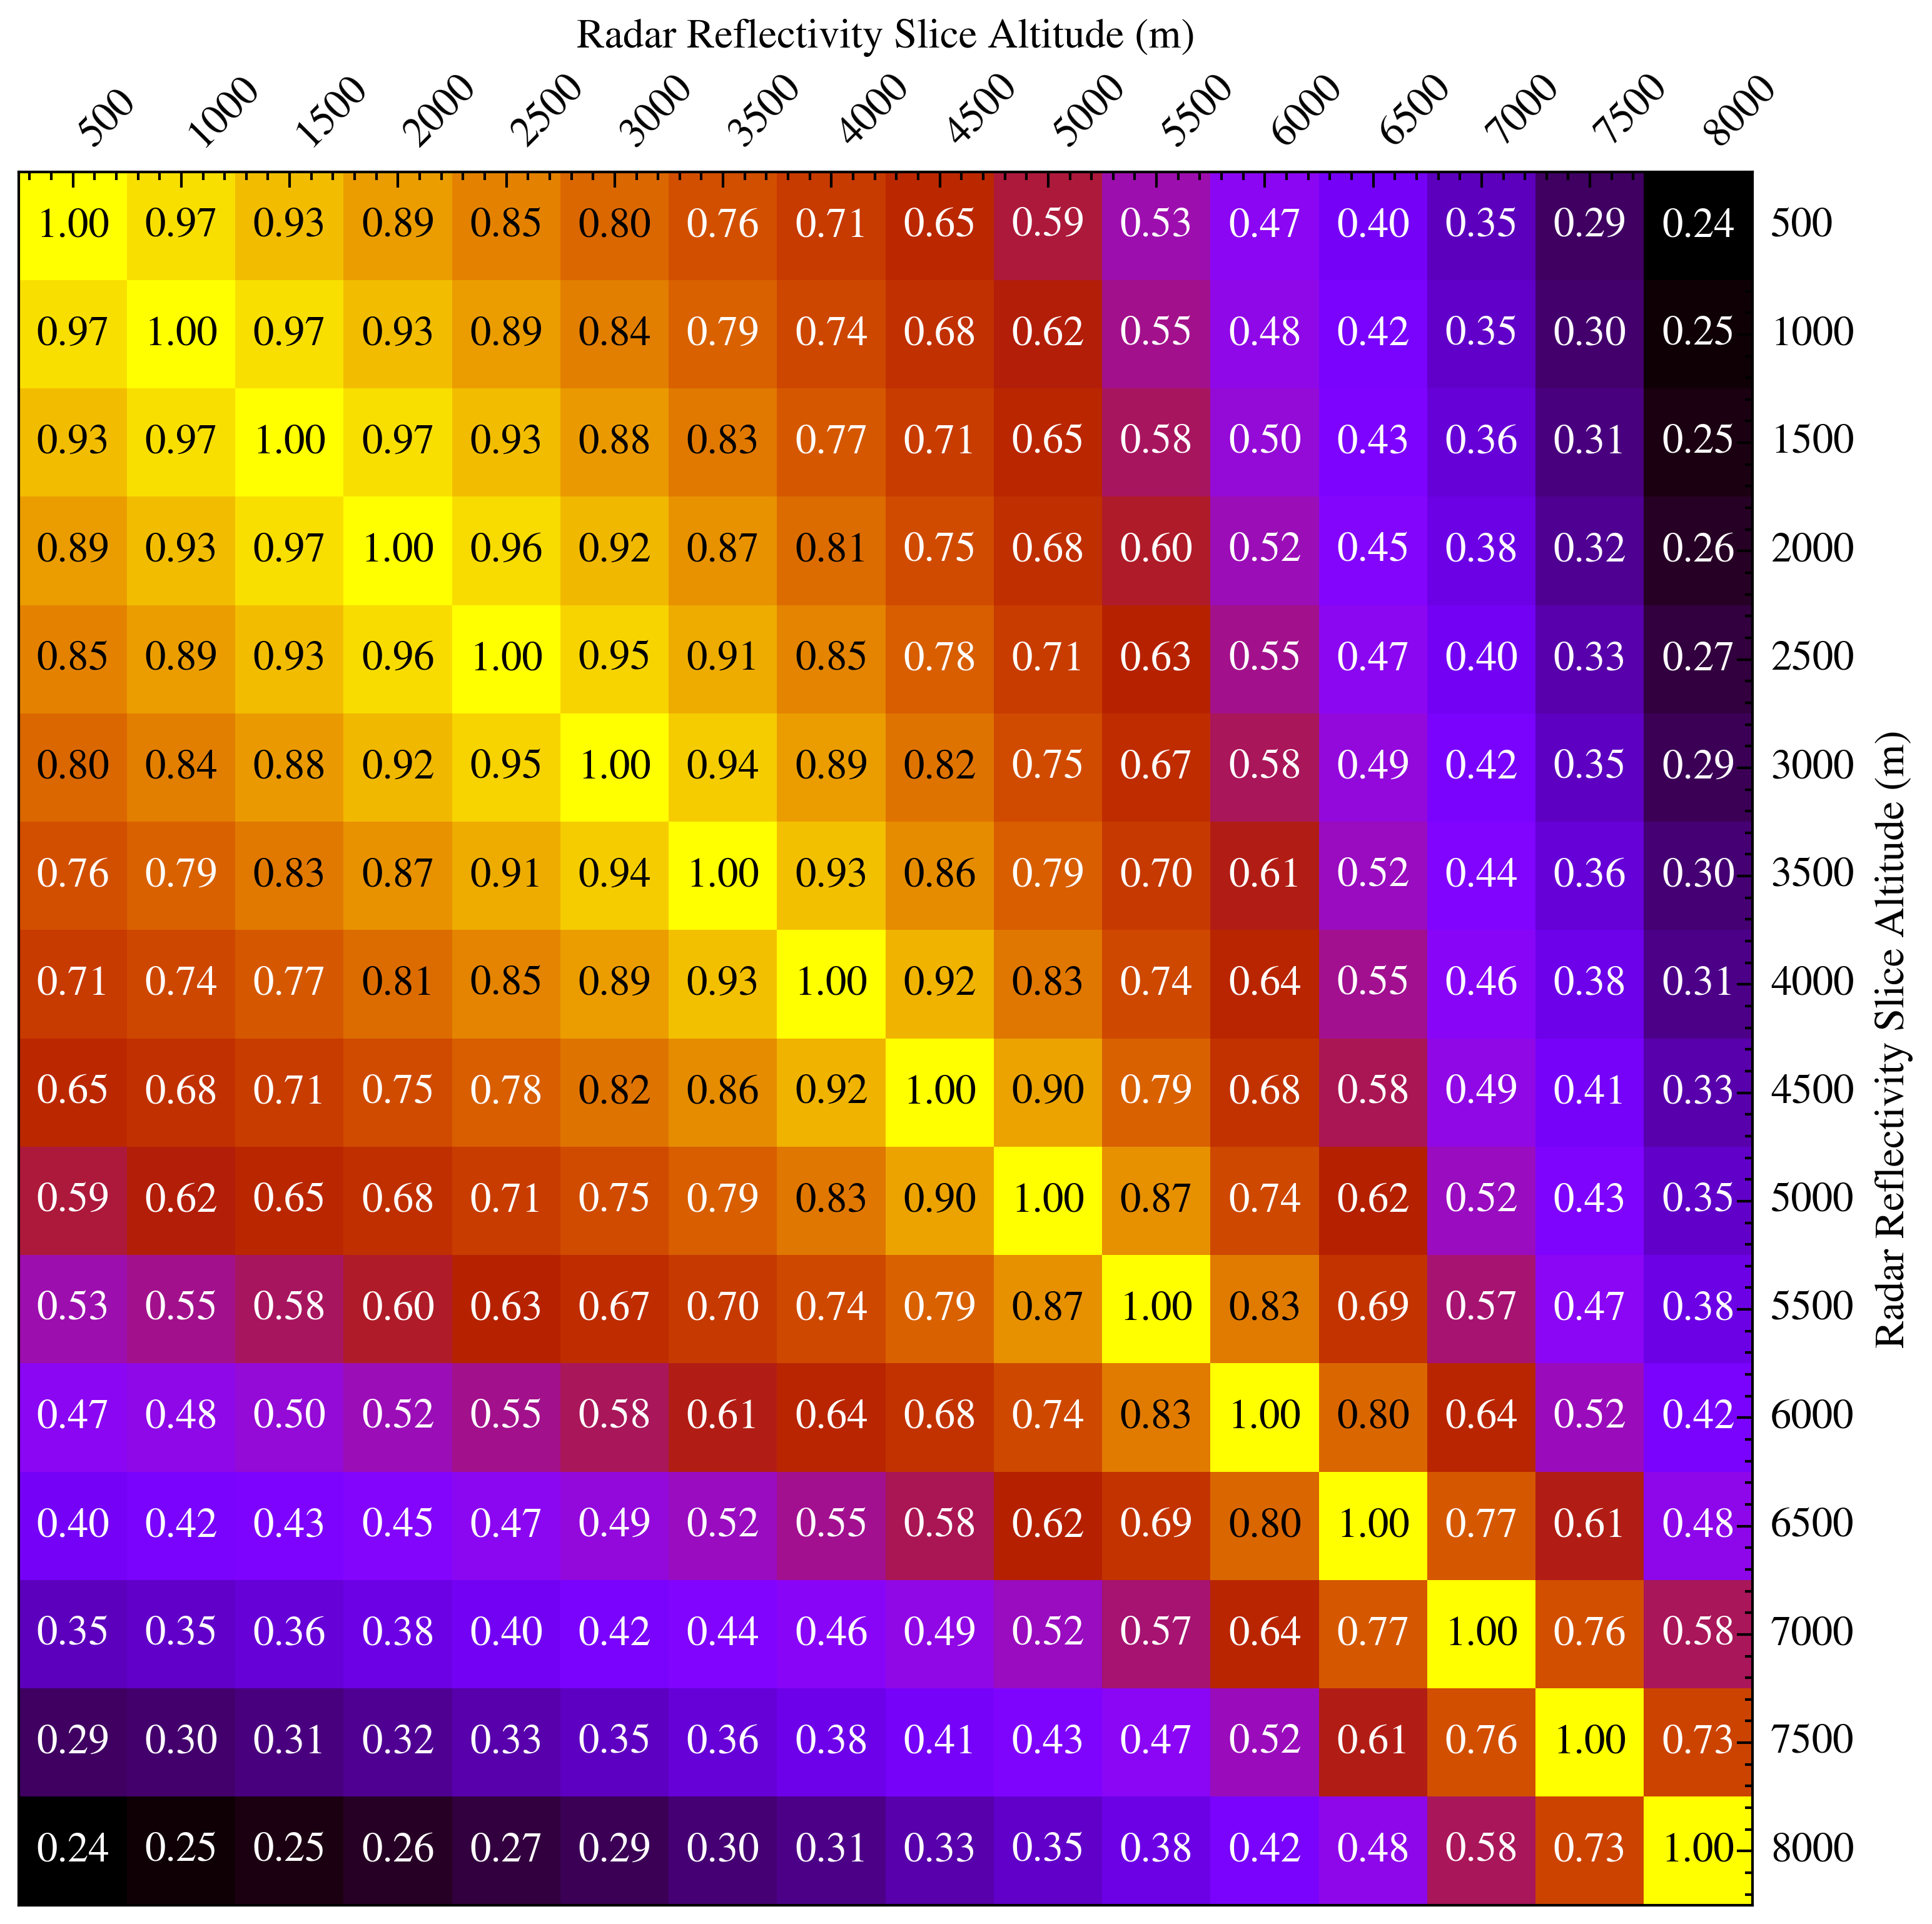

In [35]:
import numpy as np
import matplotlib.pyplot as plt

import scienceplots

plt.style.use(['science','no-latex'])

corr_matrix = np.ones((16, 16))

for corr in mean_corr:
    corr_matrix[corr] = mean_corr[corr]
    corr_matrix[(corr[1], corr[0])] = mean_corr[corr]

plt.figure(figsize=(6, 6))
plt.xticks(ticks=range(16), labels=(np.arange(16)+1)*500, rotation=45, ha='left')
plt.yticks(ticks=range(16), labels=(np.arange(16)+1)*500, rotation=0, va='center')
ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')
plt.xlabel("Radar Reflectivity Slice Altitude (m)")
plt.ylabel("Radar Reflectivity Slice Altitude (m)")

plt.imshow(corr_matrix, vmax=1, cmap='gnuplot')

# Add rounded correlation values as text
for i in range(16):
    for j in range(16):
        if not np.isnan(corr_matrix[i, j]) and corr_matrix[i, j] < 0.8:
            text = ax.text(j, i, f'{corr_matrix[i, j]:.2f}',
                           ha="center", va="center", color="w", fontsize=8)
        else:
            text = ax.text(j, i, f'{corr_matrix[i, j]:.2f}',
                           ha="center", va="center", color="black", fontsize=8)

plt.savefig("reflectivity_corr.pdf", bbox_inches='tight')

In [36]:
import numpy as np

data = np.load("altitude_wise_sample_wise_ratios.npz", allow_pickle=True)

ratios = data["corrs"]

In [4]:
total = 517 * 755
total

390335

In [37]:
def _count_precip_ratios(i):
    idx = [i]

    x, _, _ = ds[idx[0]]

    # number of altitude levels
    n_altitudes = x.shape[2]

    results = {}

    for z in range(n_altitudes):
        p = x[0, 0, z]

        ratio_mask_0 = p > 0
        ratio_mask_20 = p > 20
        ratio_mask_40 = p > 40

        pixels = x.shape[-2] * x.shape[-1]

        results[(z, 0)] = ratio_mask_0.sum().cpu().item() / pixels
        results[(z, 20)] = ratio_mask_20.sum().cpu().item() / pixels
        results[(z, 40)] = ratio_mask_40.sum().cpu().item() / pixels
    return results

In [38]:
sums = sum_dicts_by_key(ratios)

mean_corr = scale_dict(sums, len(ratios))
# mean_corr = scale_dict(mean_corr, 517 * 755)
mean_corr

{(0, 0): 0.19397791645969292,
 (0, 20): 0.057727332127472504,
 (0, 40): 0.0008642828518864246,
 (1, 0): 0.19690341966962807,
 (1, 20): 0.052142634698625415,
 (1, 40): 0.0008347583412026545,
 (2, 0): 0.19558337064085893,
 (2, 20): 0.04480196857039287,
 (2, 40): 0.0007976335954708965,
 (3, 0): 0.19107933817454617,
 (3, 20): 0.03741129039405927,
 (3, 40): 0.0007133369383901485,
 (4, 0): 0.18357048497112208,
 (4, 20): 0.030904899282675997,
 (4, 40): 0.0005637251173037276,
 (5, 0): 0.17283308176337756,
 (5, 20): 0.02537500309667563,
 (5, 40): 0.00046663814601716474,
 (6, 0): 0.15804869513674213,
 (6, 20): 0.020887851117323757,
 (6, 40): 0.00039259818940090064,
 (7, 0): 0.13957760429843835,
 (7, 20): 0.017284299001365508,
 (7, 40): 0.00032948940511039556,
 (8, 0): 0.1185312227931466,
 (8, 20): 0.01436475227914939,
 (8, 40): 0.0002742717193323212,
 (9, 0): 0.09678595720245951,
 (9, 20): 0.011929260049519363,
 (9, 40): 0.00022680177143588533,
 (10, 0): 0.07569017497759019,
 (10, 20): 0.0098125

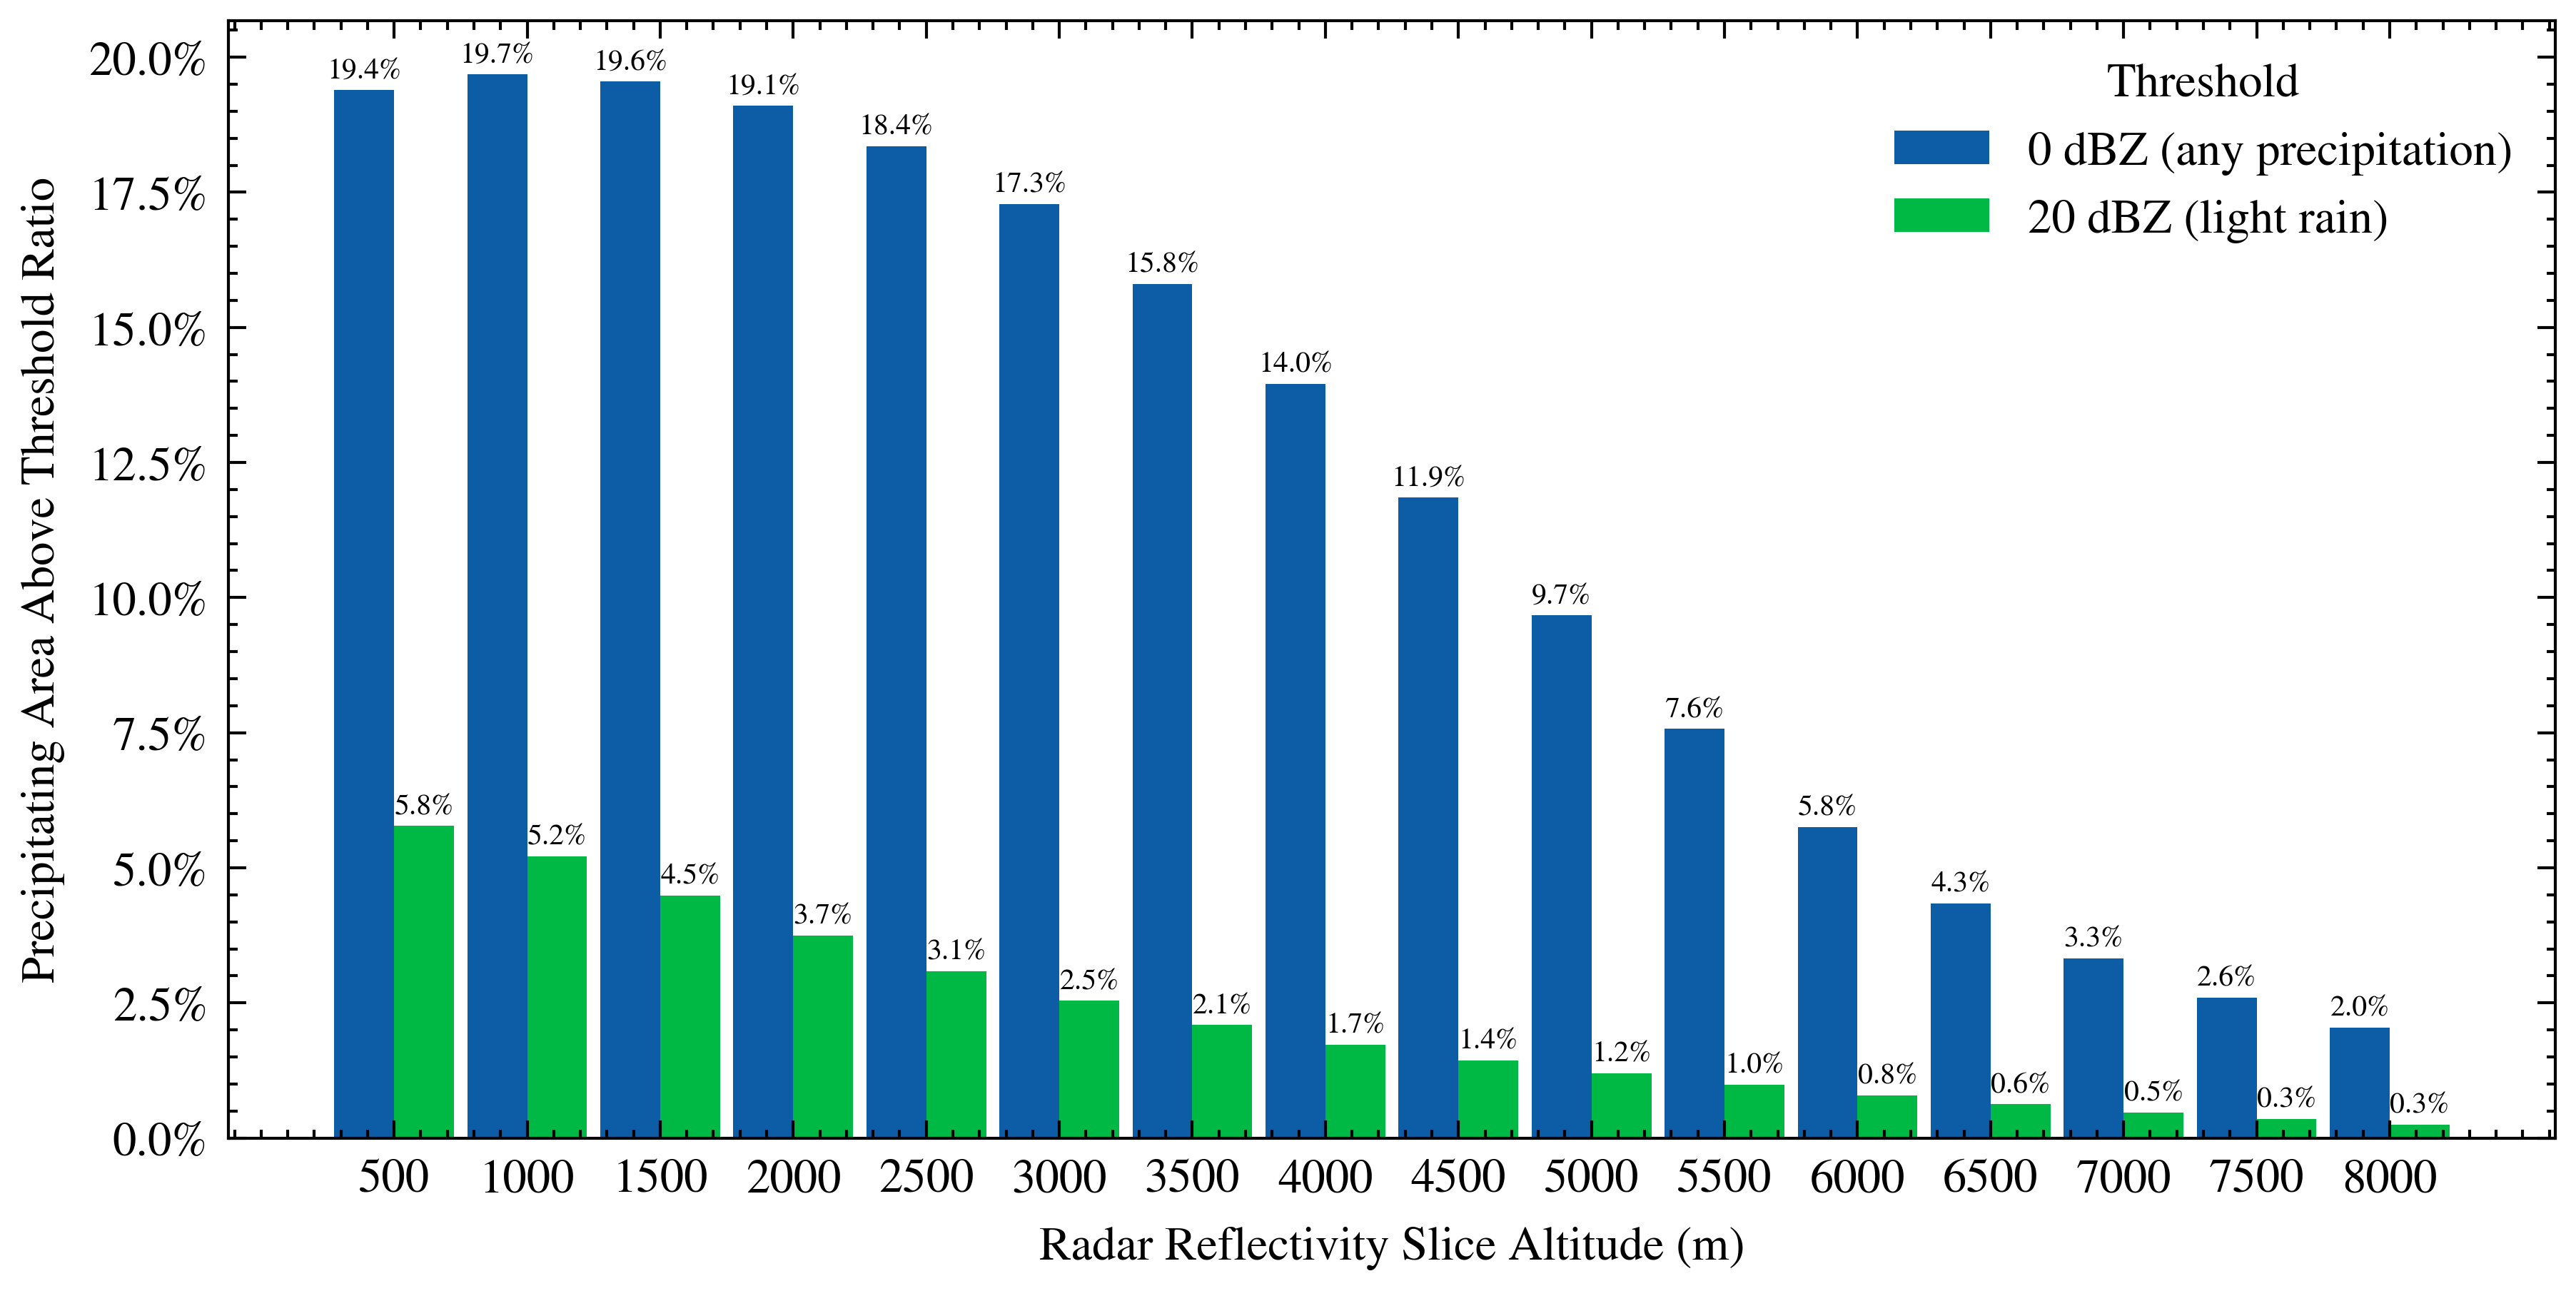

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick

import scienceplots

plt.style.use(['science','no-latex'])

altitudes = (np.arange(16) + 1) * 500
ratios_0 = [mean_corr[(z, 0)] for z in range(16)]
ratios_20 = [mean_corr[(z, 20)] for z in range(16)]
ratios_40 = [mean_corr[(z, 40)] for z in range(16)]

x = np.arange(len(altitudes))  # the label locations
width = 0.45  # the width of the bars
multiplier = 0.5

fig, ax = plt.subplots(layout='constrained', figsize=(6, 3))

for threshold in [0, 20]:
    offset = width * multiplier
    if threshold == 0:
        rects = ax.bar(x + offset, ratios_0, width, label='0 dBZ (any precipitation)')
    elif threshold == 20:
        rects = ax.bar(x + offset, ratios_20, width, label='20 dBZ (light rain)')
    else:
        rects = ax.bar(x + offset, ratios_40, width, label='40 dBZ')
    ax.bar_label(rects, padding=1, fmt='{:.1%}', fontsize=5)
    multiplier += 1

ax.set_xticks(x + width, altitudes)
ax.legend(loc='upper right', title="Threshold")
#ax.set_yscale('log')
ax.set_xlabel("Radar Reflectivity Slice Altitude (m)")
ax.set_ylabel("Precipitating Area Above Threshold Ratio")

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.savefig("reflectivity_bars.pdf", bbox_inches='tight')